# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

##### Uniform Distribution

##### Concept

A **uniform distribution** means that all values within a given interval have equal probability.

If:
- $a$ = lower bound  
- $b$ = upper bound  

Then:

$$
X \sim U(a, b)
$$

----

In [3]:
## Method 1: Using NumPy

# parameters
a = 0
b = 10
n = 1000  # number of samples

# generate random numbers
uniform_np = np.random.uniform(a, b, n)

# preview
print(uniform_np[:10])

[7.73482642 4.45999796 9.2483535  7.70559088 0.20035481 8.61495677
 5.51852702 0.37967618 6.12371017 0.6152523 ]


In [5]:
## Method 2: Using SciPy

from scipy.stats import uniform

# parameters
a = 0       # starting point
width = 10  # IMPORTANT: this is (b - a), not the endpoint

# generate random numbers
uniform_sp = uniform.rvs(loc=a, scale=width, size=1000)

# preview
print(uniform_sp[:10])

[4.07677972 2.26290691 6.25285595 2.34071361 7.46489217 7.01857418
 3.11342211 5.33133616 3.40239194 3.11721516]


**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

##### Uniform Distribution Function

##### Step 1: Define Function

In [64]:
def generate_uniform(bottom, ceiling, count):
    return np.random.uniform(bottom, ceiling, count)

##### Step 2: Generating Data

In [65]:
# first set
data1 = generate_uniform(10, 15, 100)

# second set
data2 = generate_uniform(10, 60, 1000)

##### Step 3: Plot Histograms

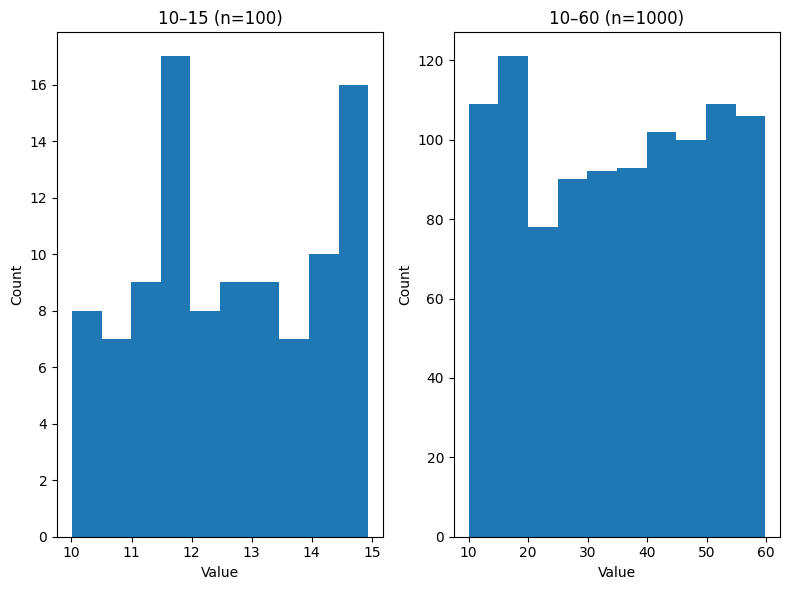

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# function
def generate_uniform(bottom, ceiling, count):
    return np.random.uniform(bottom, ceiling, count)

# generate data
data1 = generate_uniform(10, 15, 100)
data2 = generate_uniform(10, 60, 1000)

# create side-by-side plots
fig, axes = plt.subplots(1, 2)

# first plot
axes[0].hist(data1, bins=10)
axes[0].set_title("10–15 (n=100)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# second plot
axes[1].hist(data2, bins=10)
axes[1].set_title("10–60 (n=1000)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

How are the two distributions different?

1. Smoothness (most important difference)
    * Left (n=100):
        - Uneven bars
        - Random spikes and dips
        - Looks “messy”
    * Right (n=1000):
        - Much flatter
        - Bars are more consistent
        - Looks closer to a perfect uniform shape

    * This is sample size effect, not a different distribution

2. Stability of frequencies
    * Left:
        - Some bins have noticeably more counts than others
    * Right:
        - Counts are more evenly distributed across bins

    * Larger sample = more stable frequencies

* To Conclude:

    * Both distributions are uniform, but the larger sample size produces a smoother and more stable histogram that better approximates the true distribution. The difference in range only affects the spread, not the shape.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

##### Normal Distribution

##### Step 1: Define Function

In [67]:

from scipy.stats import norm 

def generate_normal(mean, std, count):
    return norm.rvs(loc=mean, scale=std, size=count)

##### Step 2: Generate Data

In [68]:
# same mean, different standard deviations

data1 = generate_normal(10, 1, 1000)
data2 = generate_normal(10, 50, 1000)

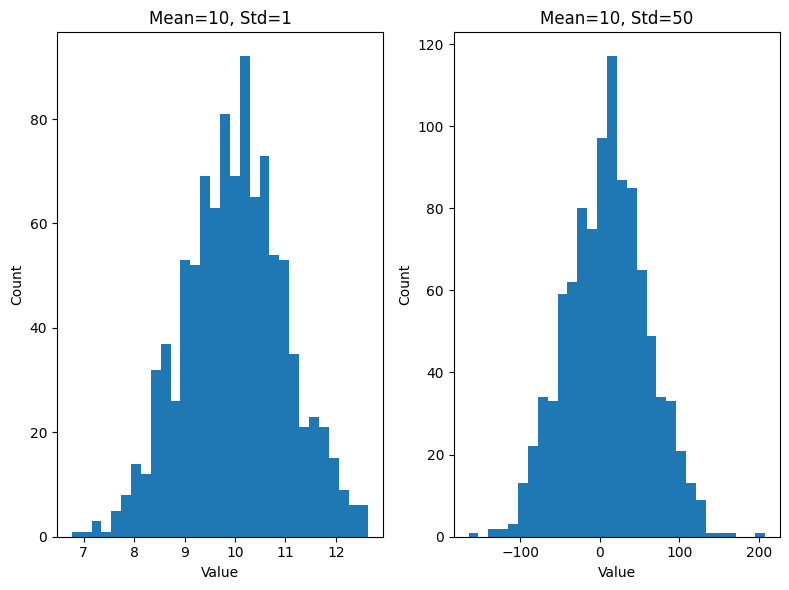

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

# std = 1
axes[0].hist(data1, bins=30)
axes[0].set_title("Mean=10, Std=1")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# std = 50
axes[1].hist(data2, bins=30)
axes[1].set_title("Mean=10, Std=50")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

How are the two distributions different?

* Both distributions have the same Mean, but the one with a higher Standard Deviation is much more spread out, resulting in a flatter and wider shape, indicating greater variability - wherein the Mean controls where the distribution is and the Standard Deviation controls how wide it spreads.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [70]:
## Step 1: Import Dataset

# load dataset
df = pd.read_csv("vehicles.csv")

# preview
df.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

In [71]:
## Inspecting the Column 

df["Fuel Barrels/Year"].describe()

count    35952.000000
mean        17.609056
std          4.467283
min          0.060000
25%         14.699423
50%         17.347895
75%         20.600625
max         47.087143
Name: Fuel Barrels/Year, dtype: float64

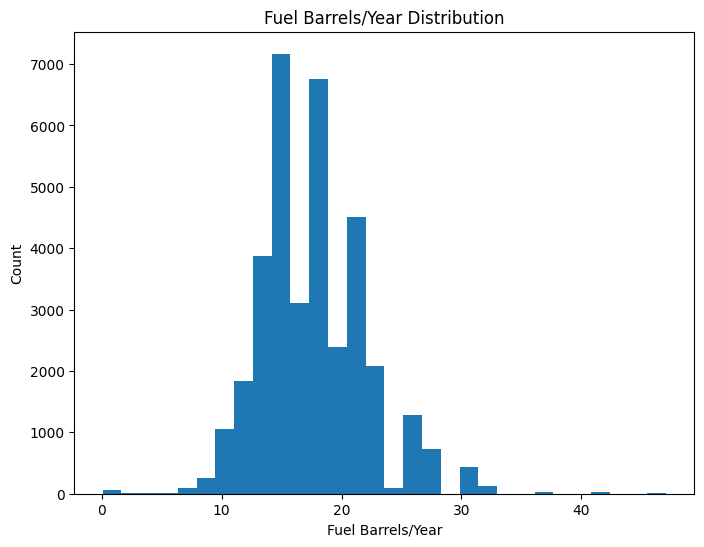

In [72]:
## Plotting Histogram

plt.figure()
plt.hist(df["Fuel Barrels/Year"].dropna(), bins=30)

plt.title("Fuel Barrels/Year Distribution")
plt.xlabel("Fuel Barrels/Year")
plt.ylabel("Count")

plt.show()

2. CO2 Emission Grams/Mile 

In [73]:
## Inspecting CO2 Emission Grams/Mile Column

df["CO2 Emission Grams/Mile"].describe()

count    35952.000000
mean       475.316339
std        119.060773
min         37.000000
25%        395.000000
50%        467.736842
75%        555.437500
max       1269.571429
Name: CO2 Emission Grams/Mile, dtype: float64

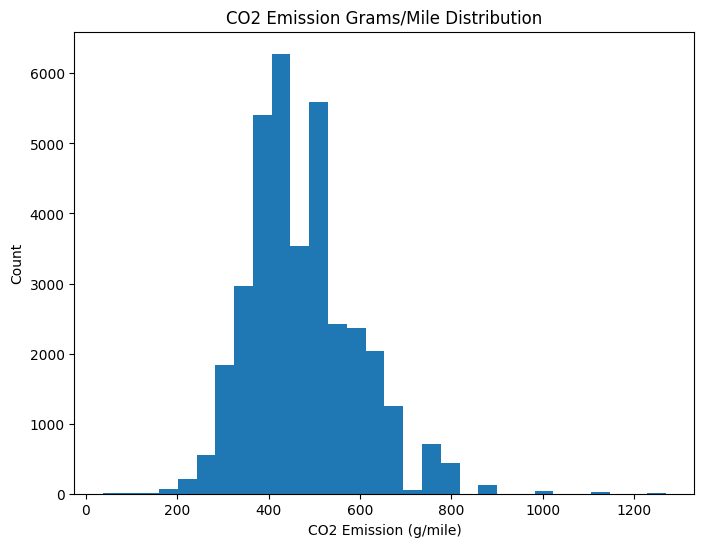

In [74]:
## Plotting the Histogram

plt.figure()
plt.hist(df["CO2 Emission Grams/Mile"].dropna(), bins=30)

plt.title("CO2 Emission Grams/Mile Distribution")
plt.xlabel("CO2 Emission (g/mile)")
plt.ylabel("Count")

plt.show()

3. Combined MPG

In [75]:
## Inspecting the Combined MPG Column

df["Combined MPG"].describe()

count    35952.000000
mean        19.929322
std          5.112409
min          7.000000
25%         16.000000
50%         19.000000
75%         23.000000
max         56.000000
Name: Combined MPG, dtype: float64

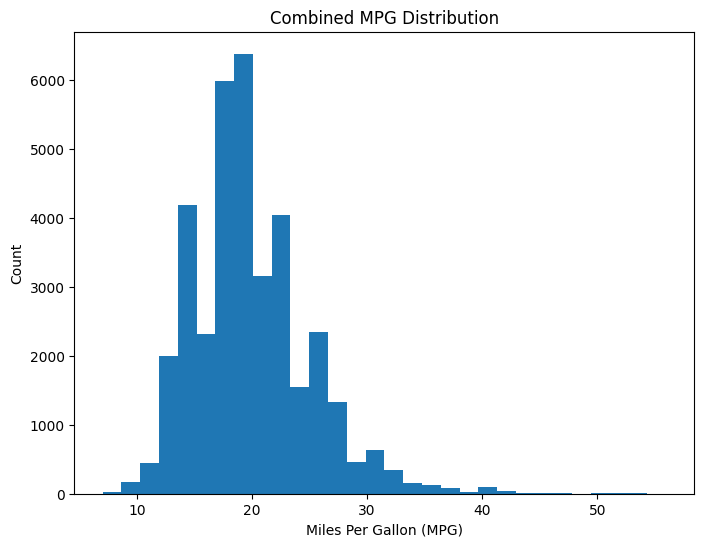

In [76]:
## Plotting the Histogram

plt.figure()
plt.hist(df["Combined MPG"].dropna(), bins=30)

plt.title("Combined MPG Distribution")
plt.xlabel("Miles Per Gallon (MPG)")
plt.ylabel("Count")

plt.show()

Which one(s) of the variables are nearly normally distributed? How do you know?

##### Checking Normality of Variables

##### Variables:
- Fuel Barrels/Year
- CO2 Emission Grams/Mile
- Combined MPG

----

##### Step 1: Plot Distributions

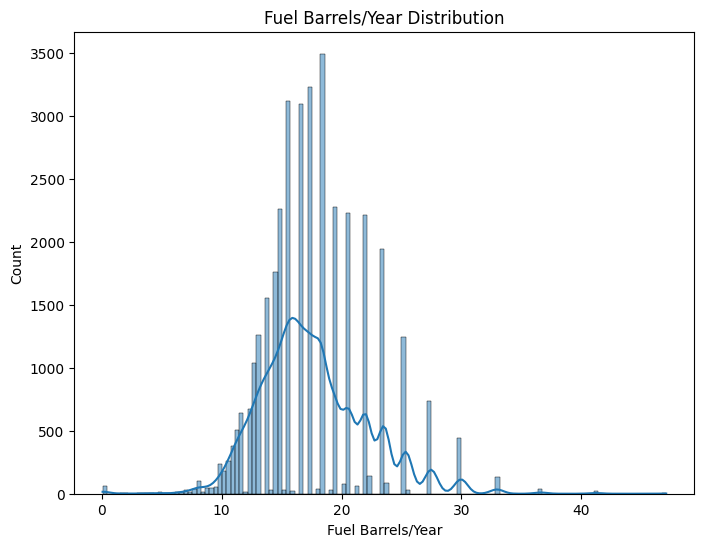

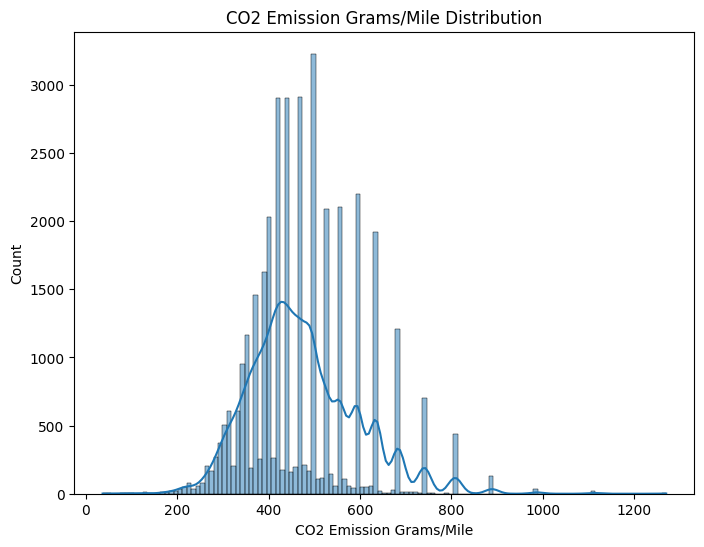

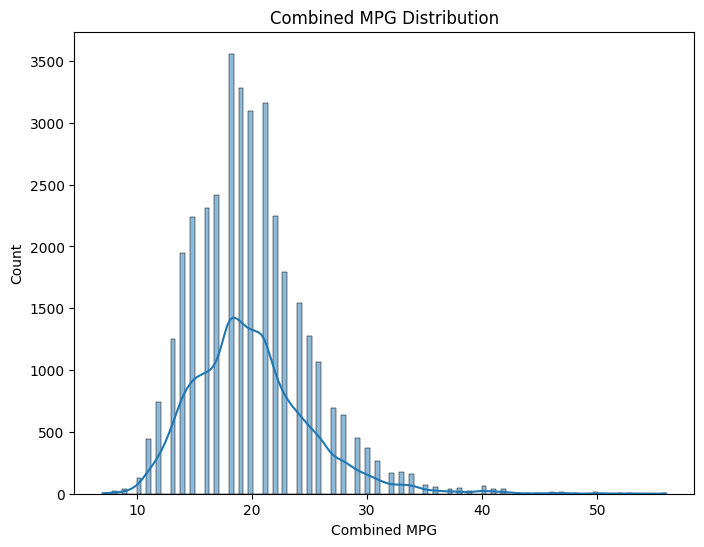

In [77]:
cols = ["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"]

for col in cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

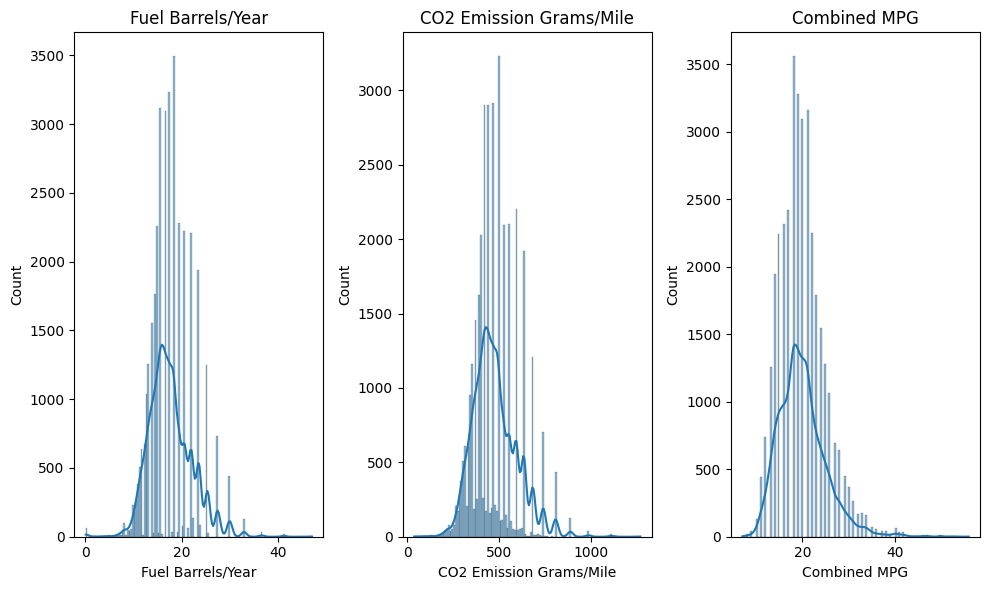

In [39]:
## PLotting the Histograms Side by Side for an easier access for visual comparison

cols = ["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"]

fig, axes = plt.subplots(1, 3)
plt.rcParams["figure.figsize"] = (8, 6)

for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

* **Final Answer**

    - None of the variables are perfectly normally distributed. This is supported by:

        - Skewed histograms (visual evidence)

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [78]:
## Step 1: Define Function

def generate_exponential(mean, count):
    # In numpy, scale = mean
    return np.random.exponential(scale=mean, size=count)

In [79]:
## Step 2: Generate Data

data1 = generate_exponential(10, 10)
data2 = generate_exponential(10, 100)


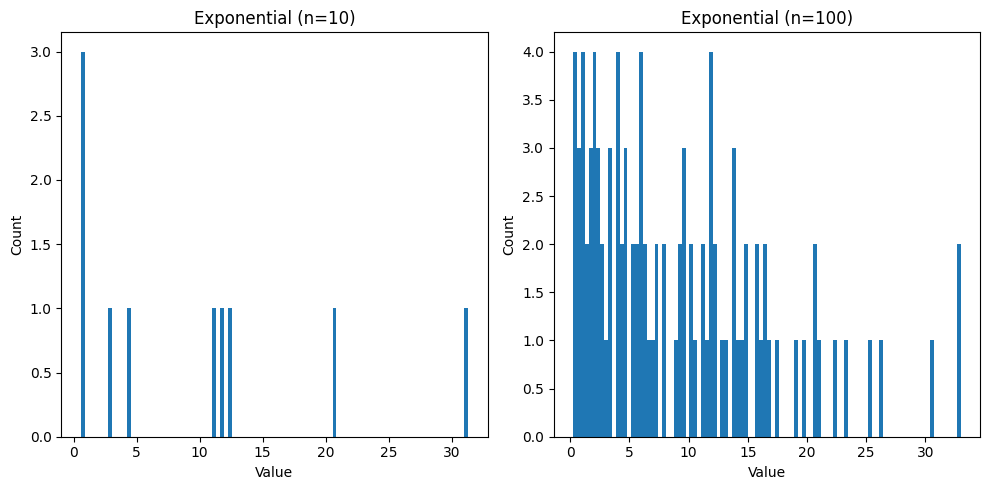

In [80]:
## Step 3: PLotting the Histograms Side by Side for an easier access for visual comparison

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# small sample
axes[0].hist(data1, bins=100)
axes[0].set_title("Exponential (n=10)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# larger sample
axes[1].hist(data2, bins=100)
axes[1].set_title("Exponential (n=100)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

How are the two distributions different?

- The histogram with a smaller sample size (n=10) is much more irregular, with random spikes and dips. The distribution does not clearly show the expected exponential decay shape due to the small number of data points.
- The histogram with a larger sample size (n=100) is much smoother and more closely resembles the theoretical exponential distribution, with a high frequency near zero that decays as values increase.
- In summary, the main difference is that the larger sample size produces a histogram that better approximates the true exponential distribution, while the smaller sample size results in more random variation and less reliable representation of the distribution's shape.

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

##### Given:

- Mean = 10 minutes  
- $\lambda = 0.1$  
- $t = 15$

---

##### Step 1: Probability of spending less than 15 minutes

CDF of exponential:

$$
P(X < t) = 1 - e^{-\lambda t}
$$

---

In [81]:
## Step 2: Compute Using Python

# Exponential distribution parameters

mean = 10  # mean time in minutes
lmbda = 1 / mean  # rate parameter

# Probability that a customer spends less than 15 minutes
from scipy.stats import expon

prob_less_15 = expon.cdf(15, scale=mean)
print(f"P(X < 15) = {prob_less_15:.3f}")


P(X < 15) = 0.777


In [82]:
## Alternatively

import math

lam = 0.1
t = 15

p_less_15 = 1 - math.exp(-lam * t)
print("P(X < 15):", round(p_less_15, 3))

P(X < 15): 0.777


In [83]:
# The probability that a customer spends less than 15 minutes in the bank is:
print(f"Probability: {prob_less_15:.3f}")

Probability: 0.777


What is the probability that the customer will spend more than 15 minutes

In [84]:
# Probability that a customer spends more than 15 minutes
prob_more_15 = 1 - prob_less_15
print(f"P(X > 15) = {prob_more_15:.3f}")

P(X > 15) = 0.223
